In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"C:\Users\naren\Downloads\synthetic_road_accidents_100k.csv")

In [3]:
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,rural,2,0.29,70,night,rainy,False,True,evening,False,False,1,0.64
1,highway,1,0.34,25,dim,clear,False,False,morning,False,False,3,0.27
2,rural,2,0.76,70,night,foggy,True,False,evening,True,True,1,0.76
3,rural,3,0.37,70,night,foggy,True,False,morning,False,True,0,0.60
4,highway,3,0.39,45,dim,rainy,False,True,morning,False,False,0,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,rural,2,0.61,60,dim,foggy,False,True,evening,False,False,1,0.54
99996,rural,2,0.52,35,dim,foggy,True,True,afternoon,False,False,1,0.18
99997,rural,2,0.08,70,daylight,clear,False,False,evening,True,False,1,0.20
99998,rural,1,0.83,70,dim,foggy,False,True,morning,False,True,0,0.58


In [4]:
df.isnull().sum()

road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [5]:
df.describe()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,2.495300,0.500619,47.054550,1.50308,0.382613
std,1.117958,0.288691,16.321527,1.22866,0.178692
min,1.000000,0.000000,25.000000,0.00000,0.000000
25%,1.000000,0.250000,35.000000,1.00000,0.250000
50%,2.000000,0.500000,45.000000,1.00000,0.380000
75%,3.000000,0.750000,60.000000,2.00000,0.510000
max,4.000000,1.000000,70.000000,10.00000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               100000 non-null  object 
 1   num_lanes               100000 non-null  int64  
 2   curvature               100000 non-null  float64
 3   speed_limit             100000 non-null  int64  
 4   lighting                100000 non-null  object 
 5   weather                 100000 non-null  object 
 6   road_signs_present      100000 non-null  bool   
 7   public_road             100000 non-null  bool   
 8   time_of_day             100000 non-null  object 
 9   holiday                 100000 non-null  bool   
 10  school_season           100000 non-null  bool   
 11  num_reported_accidents  100000 non-null  int64  
 12  accident_risk           100000 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 7.2+ MB


In [7]:
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,rural,2,0.29,70,night,rainy,False,True,evening,False,False,1,0.64
1,highway,1,0.34,25,dim,clear,False,False,morning,False,False,3,0.27
2,rural,2,0.76,70,night,foggy,True,False,evening,True,True,1,0.76
3,rural,3,0.37,70,night,foggy,True,False,morning,False,True,0,0.60
4,highway,3,0.39,45,dim,rainy,False,True,morning,False,False,0,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,rural,2,0.61,60,dim,foggy,False,True,evening,False,False,1,0.54
99996,rural,2,0.52,35,dim,foggy,True,True,afternoon,False,False,1,0.18
99997,rural,2,0.08,70,daylight,clear,False,False,evening,True,False,1,0.20
99998,rural,1,0.83,70,dim,foggy,False,True,morning,False,True,0,0.58


In [8]:
cols=["road_signs_present","public_road","holiday","school_season"]
df[cols]=df[cols].astype(int)

In [9]:
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,rural,2,0.29,70,night,rainy,0,1,evening,0,0,1,0.64
1,highway,1,0.34,25,dim,clear,0,0,morning,0,0,3,0.27
2,rural,2,0.76,70,night,foggy,1,0,evening,1,1,1,0.76
3,rural,3,0.37,70,night,foggy,1,0,morning,0,1,0,0.60
4,highway,3,0.39,45,dim,rainy,0,1,morning,0,0,0,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,rural,2,0.61,60,dim,foggy,0,1,evening,0,0,1,0.54
99996,rural,2,0.52,35,dim,foggy,1,1,afternoon,0,0,1,0.18
99997,rural,2,0.08,70,daylight,clear,0,0,evening,1,0,1,0.20
99998,rural,1,0.83,70,dim,foggy,0,1,morning,0,1,0,0.58


In [10]:
df.corr(numeric_only=True)

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk
num_lanes,1.000000,-0.002669,0.000764,-0.000965,-0.001558,-0.000515,-0.000786,0.003680,0.002335
curvature,-0.002669,1.000000,-0.001403,-0.000314,-0.000070,-0.000924,-0.000934,0.001739,0.479614
speed_limit,0.000764,-0.001403,1.000000,0.000696,-0.000631,-0.002766,0.000700,-0.002247,0.493560
road_signs_present,-0.000965,-0.000314,0.000696,1.000000,0.007141,-0.002622,0.001860,0.001025,0.000451
public_road,-0.001558,-0.000070,-0.000631,0.007141,1.000000,-0.000702,-0.000884,-0.007474,-0.004570
holiday,-0.000515,-0.000924,-0.002766,-0.002622,-0.000702,1.000000,-0.002387,0.001129,-0.003658
school_season,-0.000786,-0.000934,0.000700,0.001860,-0.000884,-0.002387,1.000000,0.001185,-0.001547
num_reported_accidents,0.003680,0.001739,-0.002247,0.001025,-0.007474,0.001129,0.001185,1.000000,0.171228
accident_risk,0.002335,0.479614,0.493560,0.000451,-0.004570,-0.003658,-0.001547,0.171228,1.000000


<Axes: >

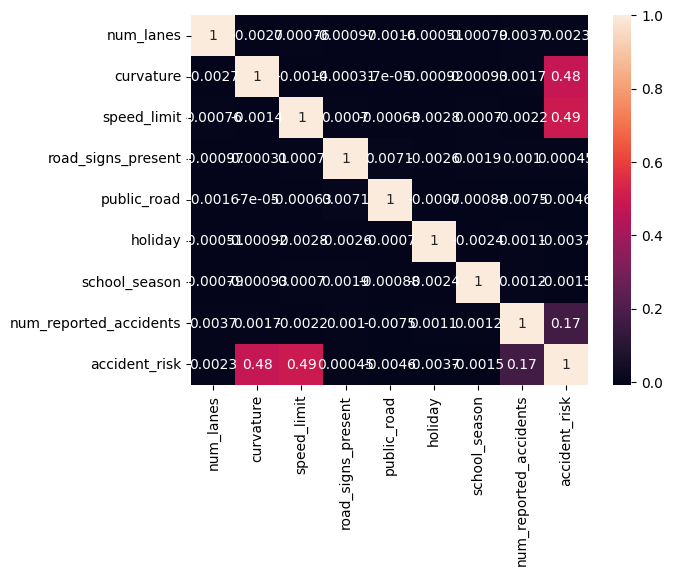

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='holiday', ylabel='accident_risk'>

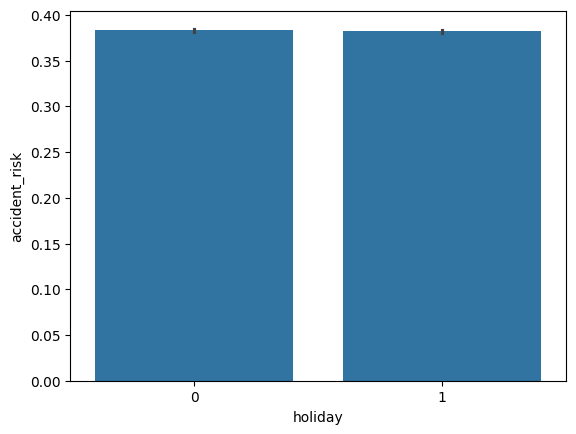

In [12]:
sns.barplot(df,y="accident_risk",x="holiday")

<Axes: xlabel='road_signs_present', ylabel='accident_risk'>

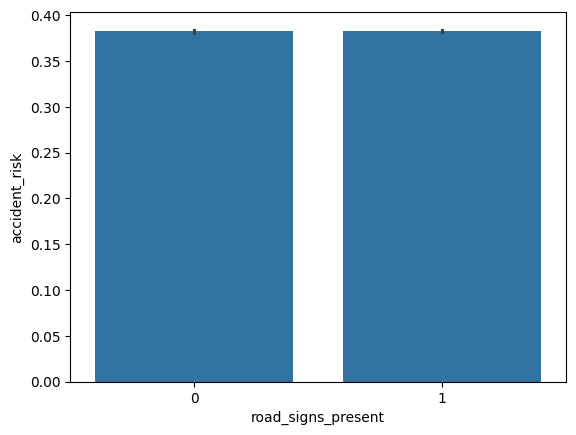

In [13]:
sns.barplot(df,y="accident_risk",x="road_signs_present")

In [14]:
df["road_signs_present"].value_counts()

road_signs_present
1    50012
0    49988
Name: count, dtype: int64

In [15]:
df["holiday"].value_counts()

holiday
1    50365
0    49635
Name: count, dtype: int64

In [16]:
df["road_type"].value_counts()

road_type
urban      33449
highway    33424
rural      33127
Name: count, dtype: int64

In [17]:
df["road_type"]=df["road_type"].map({"urban":1,"highway":2,"rural":3})
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,3,2,0.29,70,night,rainy,0,1,evening,0,0,1,0.64
1,2,1,0.34,25,dim,clear,0,0,morning,0,0,3,0.27
2,3,2,0.76,70,night,foggy,1,0,evening,1,1,1,0.76
3,3,3,0.37,70,night,foggy,1,0,morning,0,1,0,0.60
4,2,3,0.39,45,dim,rainy,0,1,morning,0,0,0,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,2,0.61,60,dim,foggy,0,1,evening,0,0,1,0.54
99996,3,2,0.52,35,dim,foggy,1,1,afternoon,0,0,1,0.18
99997,3,2,0.08,70,daylight,clear,0,0,evening,1,0,1,0.20
99998,3,1,0.83,70,dim,foggy,0,1,morning,0,1,0,0.58


In [18]:
df["lighting"].value_counts()

lighting
dim         33562
night       33251
daylight    33187
Name: count, dtype: int64

In [19]:
df["lighting"]=df["lighting"].map({"dim":1,"night":2,"daylight":3})
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,3,2,0.29,70,2,rainy,0,1,evening,0,0,1,0.64
1,2,1,0.34,25,1,clear,0,0,morning,0,0,3,0.27
2,3,2,0.76,70,2,foggy,1,0,evening,1,1,1,0.76
3,3,3,0.37,70,2,foggy,1,0,morning,0,1,0,0.60
4,2,3,0.39,45,1,rainy,0,1,morning,0,0,0,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,2,0.61,60,1,foggy,0,1,evening,0,0,1,0.54
99996,3,2,0.52,35,1,foggy,1,1,afternoon,0,0,1,0.18
99997,3,2,0.08,70,3,clear,0,0,evening,1,0,1,0.20
99998,3,1,0.83,70,1,foggy,0,1,morning,0,1,0,0.58


In [20]:
df["weather"].value_counts()

weather
clear    33511
foggy    33274
rainy    33215
Name: count, dtype: int64

In [21]:
df["weather"]=df["weather"].map({"clear":1,"foggy":2,"rainy":3})
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,3,2,0.29,70,2,3,0,1,evening,0,0,1,0.64
1,2,1,0.34,25,1,1,0,0,morning,0,0,3,0.27
2,3,2,0.76,70,2,2,1,0,evening,1,1,1,0.76
3,3,3,0.37,70,2,2,1,0,morning,0,1,0,0.60
4,2,3,0.39,45,1,3,0,1,morning,0,0,0,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,2,0.61,60,1,2,0,1,evening,0,0,1,0.54
99996,3,2,0.52,35,1,2,1,1,afternoon,0,0,1,0.18
99997,3,2,0.08,70,3,1,0,0,evening,1,0,1,0.20
99998,3,1,0.83,70,1,2,0,1,morning,0,1,0,0.58


In [22]:
df["time_of_day"]=df["time_of_day"].map({"morning":1,"afternoon":2,"evening":3})
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,3,2,0.29,70,2,3,0,1,3,0,0,1,0.64
1,2,1,0.34,25,1,1,0,0,1,0,0,3,0.27
2,3,2,0.76,70,2,2,1,0,3,1,1,1,0.76
3,3,3,0.37,70,2,2,1,0,1,0,1,0,0.60
4,2,3,0.39,45,1,3,0,1,1,0,0,0,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,2,0.61,60,1,2,0,1,3,0,0,1,0.54
99996,3,2,0.52,35,1,2,1,1,2,0,0,1,0.18
99997,3,2,0.08,70,3,1,0,0,3,1,0,1,0.20
99998,3,1,0.83,70,1,2,0,1,1,0,1,0,0.58


In [23]:
df.isnull().sum()

road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [24]:
X=df.drop(["accident_risk"],axis=1)
Y=df["accident_risk"]

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train_scaled, X_test, y_train_scaled, y_test = train_test_split(X_scaled, Y, test_size=0.20, random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression
model_lr=LinearRegression()

In [30]:
model_lr.fit(X_train_scaled,y_train_scaled)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
y_pred_lr=model_lr.predict(X_test)

In [32]:
y_pred_lr

array([0.60729897, 0.27039405, 0.25327709, ..., 0.39281942, 0.37295035,
       0.43652137], shape=(20000,))

In [33]:
from sklearn.metrics import r2_score

In [34]:
r2_score(y_test,y_pred_lr)

0.5525175676685219

In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
model_rf=RandomForestRegressor(n_estimators=100)

In [37]:
model_rf.fit(X_train_scaled,y_train_scaled)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
y_pred_rf=model_rf.predict(X_test)

In [39]:
r2_score(y_test,y_pred_rf)

0.9116055745015017

In [40]:
print(model_rf.score(X_train_scaled, y_train_scaled))
print(model_rf.score(X_test, y_test))

0.9876851896780183
0.9116055745015017


In [41]:
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,3,2,0.29,70,2,3,0,1,3,0,0,1,0.64
1,2,1,0.34,25,1,1,0,0,1,0,0,3,0.27
2,3,2,0.76,70,2,2,1,0,3,1,1,1,0.76
3,3,3,0.37,70,2,2,1,0,1,0,1,0,0.60
4,2,3,0.39,45,1,3,0,1,1,0,0,0,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,2,0.61,60,1,2,0,1,3,0,0,1,0.54
99996,3,2,0.52,35,1,2,1,1,2,0,0,1,0.18
99997,3,2,0.08,70,3,1,0,0,3,1,0,1,0.20
99998,3,1,0.83,70,1,2,0,1,1,0,1,0,0.58


In [42]:
model_rf.predict([[1,3,0.80,60,1,1,1,0,2,1,0,1]])

array([0.6208])

In [43]:
max(df["accident_risk"])

1.0

In [44]:
df[df["accident_risk"]<0.5
  ]

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
1,2,1,0.34,25,1,1,0,0,1,0,0,3,0.27
4,2,3,0.39,45,1,3,0,1,1,0,0,0,0.17
6,3,2,0.06,25,3,1,0,1,1,1,1,2,0.03
8,3,4,0.09,45,2,2,1,0,1,0,1,1,0.38
10,3,3,0.54,45,1,3,0,0,2,0,0,2,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99993,3,1,0.83,25,1,3,1,0,1,1,1,4,0.43
99994,3,1,0.49,70,1,2,0,1,1,0,0,1,0.41
99996,3,2,0.52,35,1,2,1,1,2,0,0,1,0.18
99997,3,2,0.08,70,3,1,0,0,3,1,0,1,0.20


## Classification

In [45]:
accident_risk_classified=[]
for i in df["accident_risk"]:
    if i<0.33:
        accident_risk_classified.append("Low risk")
    elif i<0.66:
        accident_risk_classified.append("Risk")
    else:
        accident_risk_classified.append("High risk")

In [46]:
accident_risk_classified

['Risk',
 'Low risk',
 'High risk',
 'Risk',
 'Low risk',
 'Risk',
 'Low risk',
 'Risk',
 'Risk',
 'Risk',
 'Low risk',
 'Risk',
 'Low risk',
 'Risk',
 'Risk',
 'Low risk',
 'Low risk',
 'Low risk',
 'Low risk',
 'Risk',
 'Risk',
 'Risk',
 'Low risk',
 'Low risk',
 'Risk',
 'Low risk',
 'Low risk',
 'Low risk',
 'Risk',
 'Risk',
 'Risk',
 'Risk',
 'Low risk',
 'Low risk',
 'Risk',
 'Low risk',
 'Risk',
 'Low risk',
 'Low risk',
 'Low risk',
 'Risk',
 'High risk',
 'Low risk',
 'Low risk',
 'Low risk',
 'Low risk',
 'High risk',
 'Low risk',
 'Low risk',
 'Low risk',
 'High risk',
 'Risk',
 'Low risk',
 'Risk',
 'Risk',
 'Risk',
 'Risk',
 'Risk',
 'Risk',
 'Risk',
 'Low risk',
 'Risk',
 'Low risk',
 'Low risk',
 'High risk',
 'Risk',
 'Low risk',
 'Low risk',
 'Risk',
 'Low risk',
 'Low risk',
 'Risk',
 'Risk',
 'Low risk',
 'Low risk',
 'Risk',
 'Low risk',
 'Risk',
 'Low risk',
 'Risk',
 'Low risk',
 'Low risk',
 'Low risk',
 'Low risk',
 'Risk',
 'Risk',
 'Risk',
 'Risk',
 'Risk',
 '

In [47]:
df["accident_risk_classified"]=accident_risk_classified

In [48]:
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,accident_risk_classified
0,3,2,0.29,70,2,3,0,1,3,0,0,1,0.64,Risk
1,2,1,0.34,25,1,1,0,0,1,0,0,3,0.27,Low risk
2,3,2,0.76,70,2,2,1,0,3,1,1,1,0.76,High risk
3,3,3,0.37,70,2,2,1,0,1,0,1,0,0.60,Risk
4,2,3,0.39,45,1,3,0,1,1,0,0,0,0.17,Low risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,2,0.61,60,1,2,0,1,3,0,0,1,0.54,Risk
99996,3,2,0.52,35,1,2,1,1,2,0,0,1,0.18,Low risk
99997,3,2,0.08,70,3,1,0,0,3,1,0,1,0.20,Low risk
99998,3,1,0.83,70,1,2,0,1,1,0,1,0,0.58,Risk


In [49]:
df["accident_risk_classified"]=df["accident_risk_classified"].map({"Low risk":0,"Risk":1,"High risk":2})

In [50]:
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,accident_risk_classified
0,3,2,0.29,70,2,3,0,1,3,0,0,1,0.64,1
1,2,1,0.34,25,1,1,0,0,1,0,0,3,0.27,0
2,3,2,0.76,70,2,2,1,0,3,1,1,1,0.76,2
3,3,3,0.37,70,2,2,1,0,1,0,1,0,0.60,1
4,2,3,0.39,45,1,3,0,1,1,0,0,0,0.17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,2,0.61,60,1,2,0,1,3,0,0,1,0.54,1
99996,3,2,0.52,35,1,2,1,1,2,0,0,1,0.18,0
99997,3,2,0.08,70,3,1,0,0,3,1,0,1,0.20,0
99998,3,1,0.83,70,1,2,0,1,1,0,1,0,0.58,1


In [51]:
df.drop("accident_risk",axis=1,inplace=True)

In [52]:
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk_classified
0,3,2,0.29,70,2,3,0,1,3,0,0,1,1
1,2,1,0.34,25,1,1,0,0,1,0,0,3,0
2,3,2,0.76,70,2,2,1,0,3,1,1,1,2
3,3,3,0.37,70,2,2,1,0,1,0,1,0,1
4,2,3,0.39,45,1,3,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,2,0.61,60,1,2,0,1,3,0,0,1,1
99996,3,2,0.52,35,1,2,1,1,2,0,0,1,0
99997,3,2,0.08,70,3,1,0,0,3,1,0,1,0
99998,3,1,0.83,70,1,2,0,1,1,0,1,0,1


In [53]:
X_classified=df.drop(["accident_risk_classified"],axis=1)
Y_classified=df["accident_risk_classified"]

In [54]:
X_scaled_classified=sc.fit_transform(X_classified)

In [55]:
X_train_classified, X_test, y_train_classified, y_test = train_test_split(X_scaled_classified, Y_classified, test_size=0.20, random_state=42)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X_classified, Y_classified, test_size=0.20, random_state=42)

In [57]:
from sklearn.neighbors import KNeighborsClassifier
model_knn=KNeighborsClassifier(n_neighbors=19)
model_knn.fit(X_train_classified,y_train_classified)

,n_neighbors,19
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [58]:
ypred_knn=model_knn.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score
acc_knn=accuracy_score(y_test,ypred_knn)

In [60]:
acc_knn

0.5255

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, ypred_knn))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      7850
           1       0.53      0.98      0.69     10712
           2       0.07      0.02      0.03      1438

    accuracy                           0.53     20000
   macro avg       0.20      0.33      0.24     20000
weighted avg       0.29      0.53      0.37     20000



In [62]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [63]:
model_dt=DecisionTreeClassifier()

In [64]:
model_dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
ypred_dt=model_dt.predict(X_test)

In [66]:
acc_dt=accuracy_score(y_test,ypred_dt)

In [67]:
acc_dt

0.82355

In [68]:
print(classification_report(y_test, ypred_dt))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      7850
           1       0.84      0.83      0.84     10712
           2       0.70      0.70      0.70      1438

    accuracy                           0.82     20000
   macro avg       0.79      0.79      0.79     20000
weighted avg       0.82      0.82      0.82     20000



In [69]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier()
model_gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [70]:
ypred_gb=model_gb.predict(X_test)

In [71]:
accuracy_score(y_test,ypred_gb)

0.87785

In [72]:
print(classification_report(y_test, ypred_gb))

              precision    recall  f1-score   support

           0       0.90      0.86      0.88      7850
           1       0.86      0.92      0.89     10712
           2       0.87      0.67      0.76      1438

    accuracy                           0.88     20000
   macro avg       0.88      0.82      0.84     20000
weighted avg       0.88      0.88      0.88     20000



In [73]:
from xgboost import XGBClassifier

In [74]:
model_xg = XGBClassifier(
    n_estimators=100,     
    max_depth=5,          
    learning_rate=0.1,    
    subsample=0.8,        
    colsample_bytree=0.8
)

model_xg.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [75]:
ypred_xg=model_gb.predict(X_test)

In [76]:
accuracy_score(y_test,ypred_xg)

0.87785

In [77]:
print(classification_report(y_test, ypred_xg))

              precision    recall  f1-score   support

           0       0.90      0.86      0.88      7850
           1       0.86      0.92      0.89     10712
           2       0.87      0.67      0.76      1438

    accuracy                           0.88     20000
   macro avg       0.88      0.82      0.84     20000
weighted avg       0.88      0.88      0.88     20000



In [78]:
from sklearn.ensemble import RandomForestClassifier

In [79]:
model_rf=RandomForestClassifier(n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42)

In [80]:
model_rf.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
ypred_rf=model_rf.predict(X_test)

In [82]:
ypred_rf

array([1, 0, 0, ..., 1, 0, 0], shape=(20000,))

In [83]:
acc_rf=accuracy_score(ypred_rf,y_test)

In [84]:
acc_rf

0.8709

In [85]:
print(classification_report(y_test, ypred_rf))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      7850
           1       0.89      0.86      0.88     10712
           2       0.70      0.89      0.78      1438

    accuracy                           0.87     20000
   macro avg       0.82      0.88      0.85     20000
weighted avg       0.87      0.87      0.87     20000



In [86]:
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk_classified
0,3,2,0.29,70,2,3,0,1,3,0,0,1,1
1,2,1,0.34,25,1,1,0,0,1,0,0,3,0
2,3,2,0.76,70,2,2,1,0,3,1,1,1,2
3,3,3,0.37,70,2,2,1,0,1,0,1,0,1
4,2,3,0.39,45,1,3,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,2,0.61,60,1,2,0,1,3,0,0,1,1
99996,3,2,0.52,35,1,2,1,1,2,0,0,1,0
99997,3,2,0.08,70,3,1,0,0,3,1,0,1,0
99998,3,1,0.83,70,1,2,0,1,1,0,1,0,1


In [87]:
model_rf.predict([[3,2,0.29,70,2,3,0,1,3,0,0,1]])

array([1])

In [88]:
import joblib
joblib.dump(model_rf, "accident_model.pkl")

['accident_model.pkl']